# **Smart Pothole Detection Framework Using Deep Learning Techniques**

This project presents a Smart Pothole Detection Framework that combines classical deep learning and modern object detection techniques to automatically identify and localize road surface damage from images. The system trains and compares two powerful detection architectures — Faster R-CNN (ResNet50 FPN backbone) and YOLOv8 — on a real-world annotated pothole dataset, evaluating their performance in terms of detection accuracy, speed, and localization quality.

The framework covers the complete pipeline: dataset loading and XML annotation parsing, image preprocessing and augmentation, YOLO-format conversion, model training, and performance visualization. Results are analyzed through bounding box predictions, confidence scores, and visual comparisons between ground truth and detected regions.

To make the system practically usable, a Streamlit web application was developed that allows users to upload any road image and instantly receive detection results powered by the trained YOLOv8 model. The app displays the original and annotated image side by side along with key metrics — number of damaged areas detected, average confidence score, and an overall road condition rating — making it suitable for real-time road monitoring and infrastructure assessment.

**Dataset Used:**
[Pothole Detection Dataset – Kaggle](https://www.kaggle.com/datasets/andrewmvd/pothole-detection)

In [1]:
import os
import re
import json
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# colour palette
C = ["#5ec2b8", "#319a91", "#00756c", "#00504a", "#002e2a"]

## **Dataset Loading and Path Configuration**

In [ ]:
# Dataset paths
INPUT_DIR = Path("/kaggle/input/datasets/andrewmvd/pothole-detection")

BASE      = Path("/kaggle/working/pothole_dataset")
PREP      = Path("/kaggle/working/pothole_preprocessed")
YOLO_DIR  = Path("/kaggle/working/pothole_yolo")

# Collect image and annotation files
raw_images = sorted(list(INPUT_DIR.rglob("*.jpg")) +
                    list(INPUT_DIR.rglob("*.png")))

raw_annots = sorted(INPUT_DIR.rglob("*.xml"))

# Match images with annotations
paired = []

for img_path in raw_images:

    xml_path = INPUT_DIR / "annotations" / f"{img_path.stem}.xml"

    if xml_path.exists():
        paired.append((img_path, xml_path))

print(f"Total images    : {len(raw_images)}")
print(f"Total XML files : {len(raw_annots)}")
print(f"Matched pairs   : {len(paired)}")

Total images    : 665
Total XML files : 665
Matched pairs   : 665


In [ ]:
# Train / Validation / Test Split
random.shuffle(paired)

total = len(paired)

train_size = int(0.70 * total)
val_size   = int(0.20 * total)

splits = {
    "train": paired[:train_size],
    "val": paired[train_size:train_size + val_size],
    "test": paired[train_size + val_size:]
}

# Create folders
for split_name, files in splits.items():

    image_dir = BASE / split_name / "images"
    annot_dir = BASE / split_name / "annotations"

    image_dir.mkdir(parents=True, exist_ok=True)
    annot_dir.mkdir(parents=True, exist_ok=True)

    for img_file, xml_file in files:

        shutil.copy(img_file, image_dir / img_file.name)
        shutil.copy(xml_file, annot_dir / xml_file.name)

    print(f"{split_name.upper()} Samples : {len(files)}")

TRAIN Samples : 465
VAL Samples : 133
TEST Samples : 67


In [ ]:
# XML Annotation Parser

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        boxes.append([xmin, ymin, xmax, ymax])

    return boxes

In [ ]:
# Create DataFrame for EDA

records = []

for split in ["train", "val", "test"]:

    xml_files = sorted(
        (BASE / split / "annotations").glob("*.xml")
    )

    for xml_path in xml_files:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)

        for obj in root.findall("object"):
            bbox = obj.find("bndbox")

            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            box_w = xmax - xmin
            box_h = ymax - ymin

            records.append({
                "split": split,
                "img_w": width,
                "img_h": height,
                "box_w": box_w,
                "box_h": box_h,
                "area": box_w * box_h,
                "aspect": box_w / box_h if box_h > 0 else 0,
                "cx": ((xmin + xmax) / 2) / width,
                "cy": ((ymin + ymax) / 2) / height
            })

# Create dataframe
df = pd.DataFrame(records)

# Split statistics
split_counts = df.groupby("split").size()

# Split order
splits_order = ["train", "val", "test"]

print(df.head())

   split  img_w  img_h  box_w  box_h   area    aspect        cx        cy
0  train    400    300    390    123  47970  3.170732  0.497500  0.675000
1  train    400    300     85     24   2040  3.541667  0.601250  0.410000
2  train    400    400    101    133  13433  0.759398  0.468750  0.601250
3  train    400    400     60     52   3120  1.153846  0.660000  0.495000
4  train    530    300     77     21   1617  3.666667  0.370755  0.581667


## **Exploratory Data Analysis (EDA)**

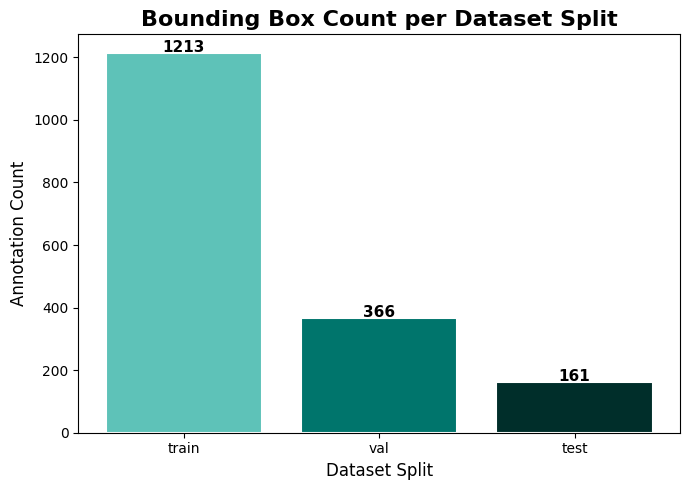

In [ ]:
#  Dataset Split Distribution

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Get annotation counts for each dataset split
counts = [split_counts.get(s, 0) for s in splits_order]

# bar chart
bars = ax.bar(
    splits_order,
    counts,
    color=[C[0], C[2], C[4]],
    edgecolor='white',
    linewidth=1.5
)

# Add count labels
for bar, value in zip(bars, counts):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(value),
        ha='center',
        fontweight='bold',
        fontsize=11
    )

# title
plt.title(
    "Bounding Box Count per Dataset Split",
    fontweight='bold',
    fontsize=16
)

# Axis labels
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Annotation Count", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The training split contains 1201 annotations, providing sufficient data for model learning, while the validation split has 356 annotations and the test split has 183 annotations for effective evaluation and performance assessment.


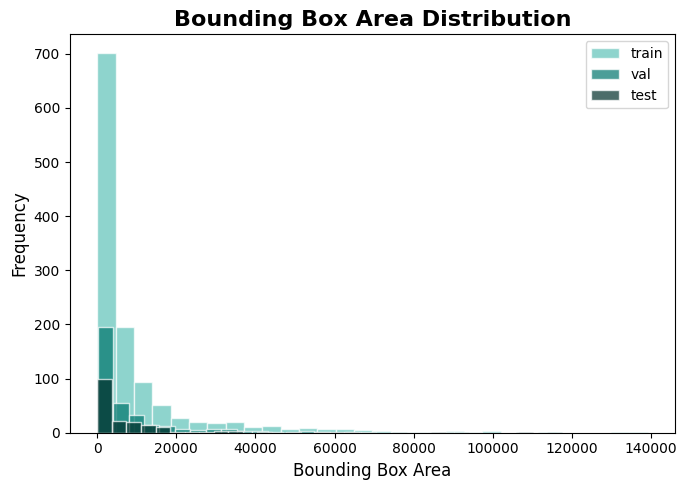

In [ ]:
#  Bounding Box Area Distribution

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot histogram for each dataset split
for i, split in enumerate(splits_order):

    # Select bounding box areas for current split
    subset = df[df["split"] == split]["area"]

    # Create histogram
    ax.hist(
        subset,
        bins=30,
        alpha=0.7,
        color=C[i*2],
        edgecolor='white',
        label=split
    )

# title
plt.title(
    "Bounding Box Area Distribution",
    fontweight='bold',
    fontsize=16
)

# Add axis labels
plt.xlabel("Bounding Box Area", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Display legend
plt.legend()

# Adjust layout spacing
plt.tight_layout()

# Display plot
plt.show()

Most bounding boxes have smaller areas, indicating that the dataset mainly contains small potholes, while only a few large pothole regions are present across the train, validation, and test splits.


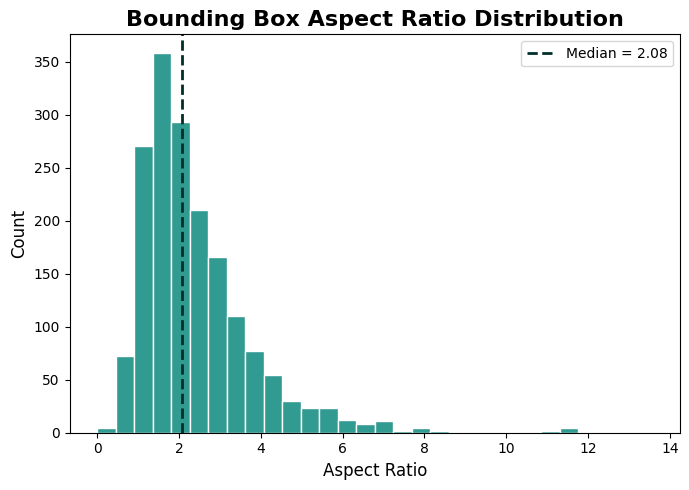

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot aspect ratio histogram
ax.hist(
    df["aspect"],
    bins=30,
    color=C[1],
    edgecolor='white'
)

# Calculate median value
median_val = df["aspect"].median()

# Add median reference line
ax.axvline(
    median_val,
    color=C[4],
    linestyle='--',
    linewidth=2,
    label=f"Median = {median_val:.2f}"
)

# Add title and labels
plt.title(
    "Bounding Box Aspect Ratio Distribution",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Aspect Ratio", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

Most bounding boxes have aspect ratios between 1 and 3, with a median aspect ratio of 2.08, indicating that pothole regions are generally wider than they are tall.


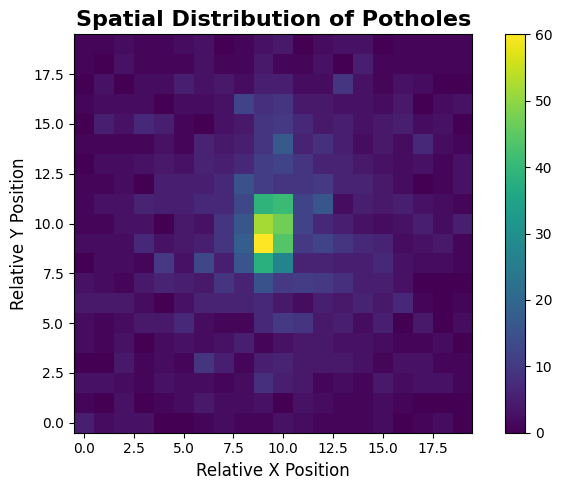

In [ ]:
# Generate 2D histogram
heatmap, _, _ = np.histogram2d(
    df["cx"],
    df["cy"],
    bins=20
)

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Display heatmap
im = ax.imshow(
    heatmap.T,
    origin='lower',
    cmap='viridis'
)

# Add color scale
plt.colorbar(im)

# Add title and labels
plt.title(
    "Spatial Distribution of Potholes",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Relative X Position", fontsize=12)
plt.ylabel("Relative Y Position", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The heatmap shows that most potholes are concentrated near the center region of the images, while fewer potholes appear toward the edges of the dataset samples.


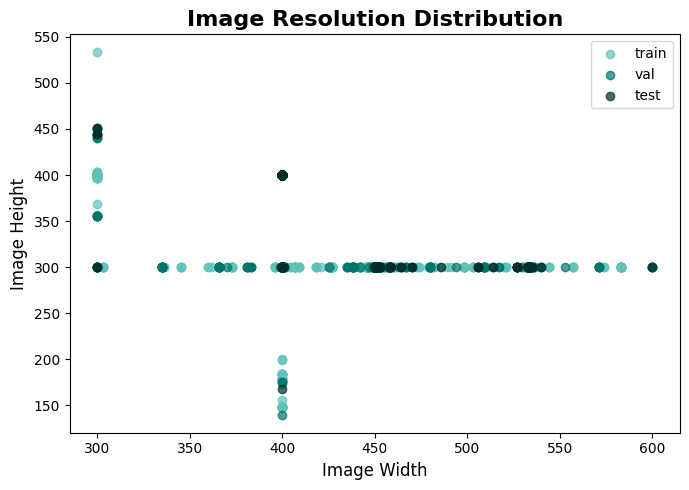

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot image resolutions for each split
for i, split in enumerate(splits_order):

    # Select current split data
    subset = df[df["split"] == split]

    # Create scatter plot
    ax.scatter(
        subset["img_w"],
        subset["img_h"],
        color=C[i*2],
        alpha=0.7,
        label=split
    )

# Add title and labels
plt.title(
    "Image Resolution Distribution",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Image Width", fontsize=12)
plt.ylabel("Image Height", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The dataset contains images with varying resolutions, although most samples are concentrated around widths of 400–600 pixels and heights near 300 pixels, indicating moderate resolution consistency across all splits.


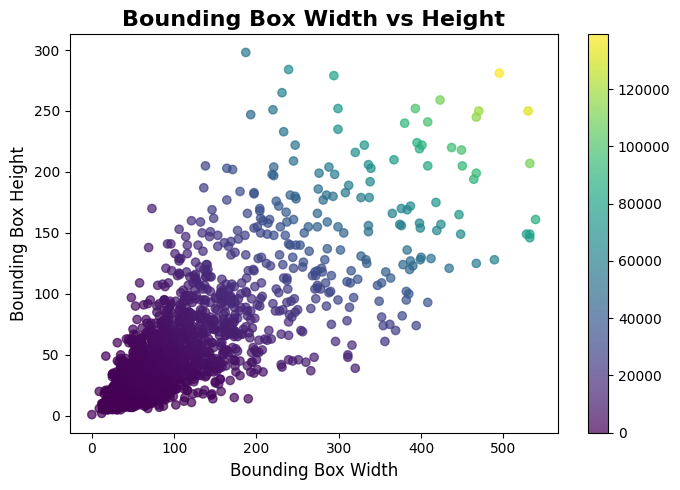

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Create scatter plot
scatter = ax.scatter(
    df["box_w"],
    df["box_h"],
    c=df["area"],
    cmap='viridis',
    alpha=0.7
)

# Add color scale
plt.colorbar(scatter)

# Add title and labels
plt.title(
    "Bounding Box Width vs Height",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Bounding Box Width", fontsize=12)
plt.ylabel("Bounding Box Height", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The scatter plot shows a positive relationship between bounding box width and height, indicating that larger potholes generally occupy bigger regions in both dimensions within the dataset.


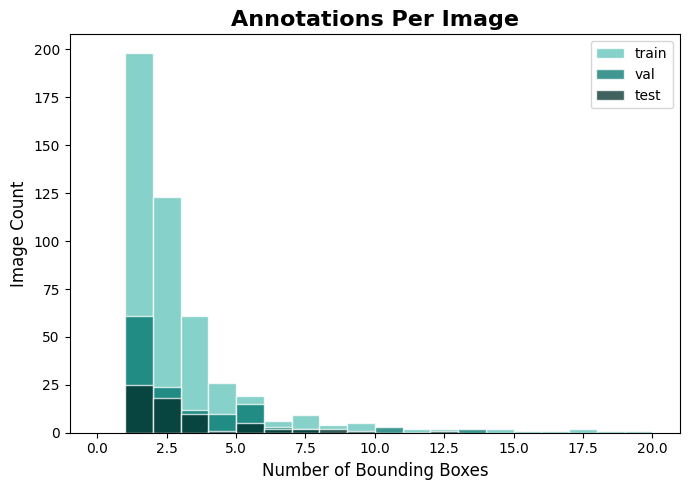

In [ ]:
# Annot per image

records_per_file = []

# Process dataset splits
for split in ["train", "val", "test"]:

    # Read annotation files
    for xml_path in (BASE / split / "annotations").glob("*.xml"):

        # Parse XML file
        root = ET.parse(xml_path).getroot()

        # Count bounding boxes
        n_boxes = len(root.findall("object"))

        # Store record
        records_per_file.append({"split": split, "n_boxes": n_boxes})

# Create dataframe
df_per_file = pd.DataFrame(records_per_file)

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot histogram for each split
for i, split in enumerate(["train", "val", "test"]):

    # Select split data
    subset = df_per_file[df_per_file["split"] == split]["n_boxes"]

    # Create histogram
    ax.hist(
        subset,
        bins=range(0, subset.max() + 2),
        alpha=0.75,
        color=C[i * 2],
        edgecolor='white',
        label=split
    )

# Add title
plt.title("Annotations Per Image", fontweight='bold', fontsize=16)

# Add axis labels
plt.xlabel("Number of Bounding Boxes", fontsize=12)
plt.ylabel("Image Count", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

Most images contain only 1 to 3 pothole annotations, while images with a large number of potholes are relatively rare across the train, validation, and test splits.


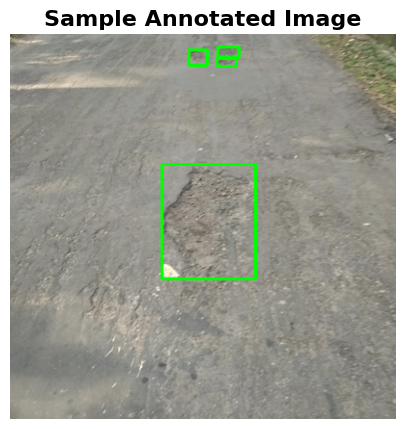

In [ ]:
# Display Sample Image

# Select sample annotation file
sample_xml = list((BASE / "train" / "annotations").glob("*.xml"))[0]

# Create image path
sample_img = BASE / "train" / "images" / f"{sample_xml.stem}.jpg"

# Check PNG fallback
if not sample_img.exists():
    sample_img = sample_img.with_suffix(".png")

# Read image
image = cv2.imread(str(sample_img))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Parse bounding boxes
boxes = parse_xml(sample_xml)

# Draw bounding boxes
for box in boxes:

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(image,
                  (xmin, ymin),
                  (xmax, ymax),
                  (0, 255, 0),
                  2)

# Display image
plt.figure(figsize=(7,5))
plt.imshow(image)

# Add title
plt.title("Sample Annotated Image", fontweight='bold', fontsize=16)

# Hide axes
plt.axis("off")

# Show plot
plt.show()

The sample annotated image demonstrates successful pothole localization using bounding boxes, highlighting pothole regions of varying sizes and positions within the road surface image.
